# Uncertainty-Aware House Value Regression

## Objective

The objective of this notebook is to predict the median house value of a
California district using demographic, geographic, and housing-related
features.

In addition to producing point predictions, the notebook applies split
conformal prediction to construct prediction intervals. These intervals
communicate the uncertainty associated with each prediction.

The notebook investigates:

- how well a Random Forest model predicts district house values;
- whether it outperforms a simple median baseline;
- how conformal prediction intervals are constructed;
- whether the intervals achieve their intended 90% coverage;
- which types of districts are most difficult to predict.

## Machine-learning task

This is a supervised regression problem:

- Input: district characteristics such as income, location, population,
  and housing information.
- Target: median house value.
- Output: a predicted house value and a corresponding prediction interval.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = kagglehub.dataset_download(
    "camnugent/california-housing-prices"
)

dataset_path = Path(dataset_path)

csv_files = list(dataset_path.rglob("housing.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"housing.csv was not found inside {dataset_path}"
    )

data_path = csv_files[0]

housing_df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {housing_df.shape}")

housing_df.head()

100%|██████████| 400k/400k [00:00<00:00, 570kB/s]

Extracting files...
Dataset path: C:\Users\ADMIN\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1\housing.csv
Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset

Each row represents a geographic district rather than an individual house.

The target variable is `median_house_value`.

Important predictors include:

- `median_income`: median income within the district;
- `housing_median_age`: median age of houses;
- `total_rooms` and `total_bedrooms`: district housing totals;
- `population`: number of residents;
- `households`: number of households;
- `longitude` and `latitude`: geographic location;
- `ocean_proximity`: categorical description of proximity to the ocean.

Because the observations represent districts, the predictions should be
interpreted as district-level median values rather than prices for specific
properties.

In [5]:
missing_summary = (
    housing_df
    .isna()
    .sum()
    .to_frame("missing_values")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"]
    / len(housing_df)
    * 100
)

missing_summary.sort_values(
    "missing_values",
    ascending=False
)

,missing_values,missing_percentage
total_bedrooms,207,1.002907
longitude,0,0.000000
latitude,0,0.000000
housing_median_age,0,0.000000
total_rooms,0,0.000000
population,0,0.000000
households,0,0.000000
median_income,0,0.000000
median_house_value,0,0.000000
ocean_proximity,0,0.000000


In [6]:
print("Number of duplicated rows:", housing_df.duplicated().sum())

print("\nOcean proximity categories:")
print(housing_df["ocean_proximity"].value_counts())

Number of duplicated rows: 0

Ocean proximity categories:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


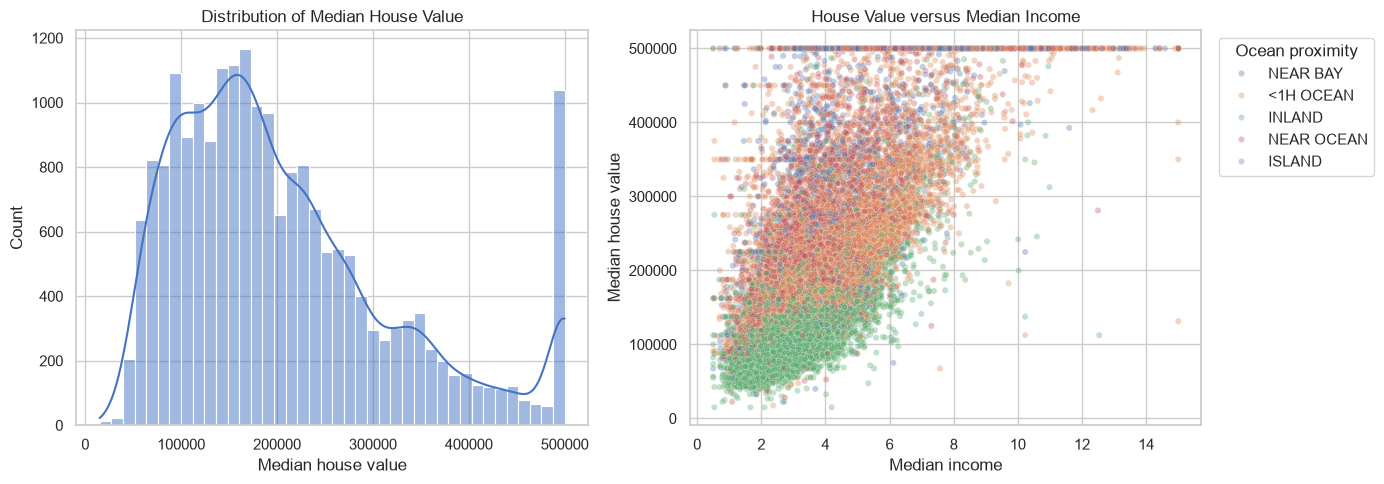

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=housing_df,
    x="median_house_value",
    bins=40,
    kde=True,
    ax=axes[0],
    color="#4472C4"
)

axes[0].set_title("Distribution of Median House Value")
axes[0].set_xlabel("Median house value")

sns.scatterplot(
    data=housing_df,
    x="median_income",
    y="median_house_value",
    hue="ocean_proximity",
    alpha=0.35,
    s=20,
    ax=axes[1]
)

axes[1].set_title("House Value versus Median Income")
axes[1].set_xlabel("Median income")
axes[1].set_ylabel("Median house value")
axes[1].legend(
    title="Ocean proximity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

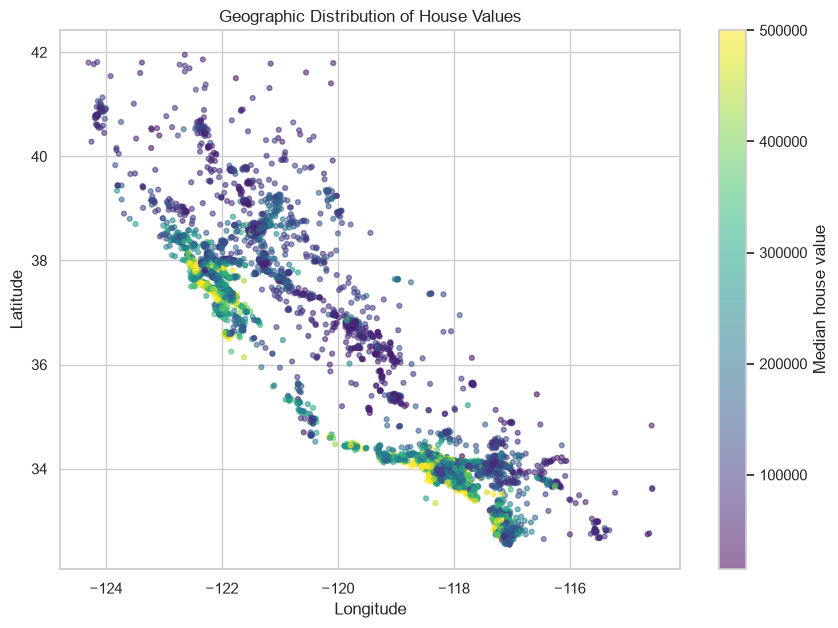

In [8]:
plt.figure(figsize=(10, 7))

sample_df = housing_df.sample(
    n=min(8000, len(housing_df)),
    random_state=RANDOM_STATE
)

scatter = plt.scatter(
    sample_df["longitude"],
    sample_df["latitude"],
    c=sample_df["median_house_value"],
    cmap="viridis",
    alpha=0.55,
    s=12
)

plt.colorbar(
    scatter,
    label="Median house value"
)

plt.title("Geographic Distribution of House Values")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

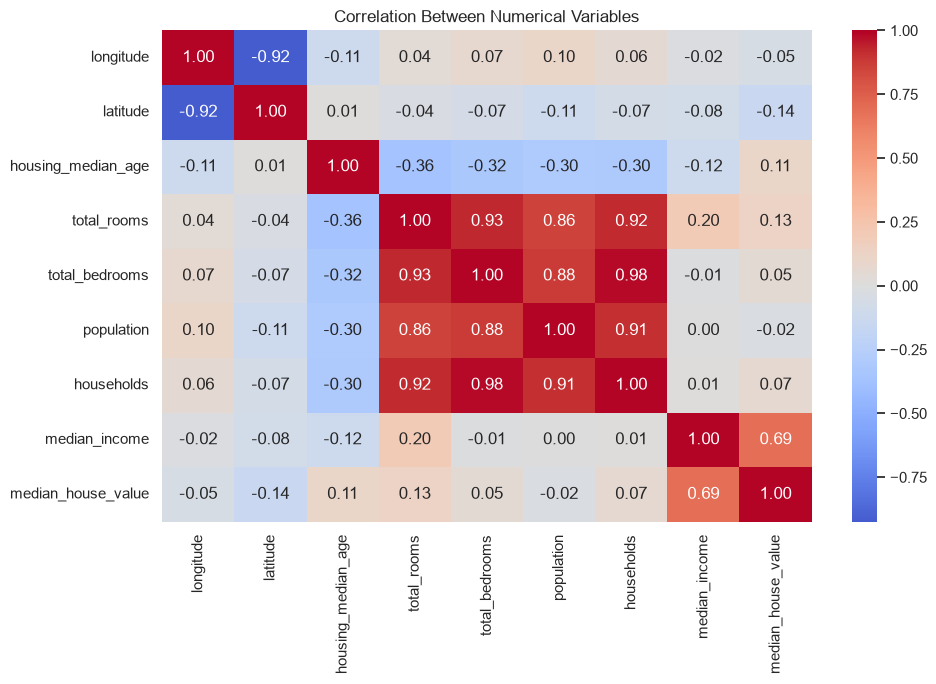

In [9]:
numeric_columns = housing_df.select_dtypes(
    include=np.number
).columns

correlation_matrix = (
    housing_df[numeric_columns]
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

### Data-quality findings

The dataset contains 20,640 observations and 10 columns. After separating
the target, the model uses eight numerical predictors and one categorical
predictor.

Only `total_bedrooms` contains missing data:

- Missing observations: 207
- Missing percentage: approximately 1.00%

These values are replaced with the training-set median inside the
preprocessing pipeline. Performing imputation inside the pipeline prevents
information from the calibration or test sets leaking into model training.

No duplicated rows were found.

The `ocean_proximity` variable contains five categories, but they are
strongly imbalanced. `<1H OCEAN` is the most common category with 9,136
observations, while `ISLAND` contains only five. Results involving the
`ISLAND` category should therefore be interpreted cautiously.

### Exploratory findings

The median house value has a mean of approximately $206,856 and a median of
$179,700. The mean being higher than the median indicates a right-skewed
distribution.

There is also a visible concentration at $500,001, which is the maximum
recorded target value. This suggests that the original dataset capped
high-value observations. Consequently, differences between expensive
districts above this threshold are unavailable to the model.

Median income shows a strong positive relationship with median house value.
However, districts with similar incomes can still have substantially
different values, indicating that income alone is insufficient for making
accurate predictions.

The geographic plot shows that house values are spatially structured.
Higher values tend to appear around coastal and major metropolitan regions,
while many inland districts have lower values. This suggests that longitude,
latitude, and ocean proximity should be important predictors.

Several district-total variables, including rooms, bedrooms, population and
households, have wide distributions. Their values partly reflect district
size rather than only housing quality.

In [10]:
TARGET_COLUMN = "median_house_value"

X = housing_df.drop(
    columns=TARGET_COLUMN
)

y = housing_df[TARGET_COLUMN]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 9)
Target shape: (20640,)


In [11]:
# First reserve 20% for final testing
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Split the remaining 80% into 60% training and 20% calibration
X_train, X_calibration, y_train, y_calibration = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print(f"Training observations:    {len(X_train):,}")
print(f"Calibration observations: {len(X_calibration):,}")
print(f"Test observations:        {len(X_test):,}")

Training observations:    12,384
Calibration observations: 4,128
Test observations:        4,128


### Data splitting strategy

The data was divided into three independent subsets:

- Training set: 12,384 observations
- Calibration set: 4,128 observations
- Test set: 4,128 observations

The training set was used to fit the preprocessing pipeline and regression
models. The calibration set was used only to estimate the conformal error
quantile. The test set was reserved for the final evaluation of both point
predictions and prediction intervals.

Keeping the calibration data separate is necessary because conformal
prediction must estimate errors using observations that were not used to
fit the regression model.

In [12]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categorical features:
['ocean_proximity']


In [13]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [19]:
from sklearn import set_config

set_config(display="text")

In [20]:
OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [21]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            DummyRegressor(strategy="median")
        )
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_features=0.8,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [25]:
baseline_pipeline.fit(
    X_train,
    y_train
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Models trained")

Models trained


In [26]:
def calculate_regression_metrics(
    model_name,
    y_true,
    y_pred
):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "R2": r2_score(
            y_true,
            y_pred
        )
    }

In [27]:
baseline_predictions = baseline_pipeline.predict(
    X_test
)

forest_predictions = random_forest_pipeline.predict(
    X_test
)

evaluation_df = pd.DataFrame(
    [
        calculate_regression_metrics(
            "Median baseline",
            y_test,
            baseline_predictions
        ),
        calculate_regression_metrics(
            "Random Forest",
            y_test,
            forest_predictions
        )
    ]
)

evaluation_df

,model,MAE,RMSE,R2
0,Median baseline,87403.653101,117322.613743,-0.050405
1,Random Forest,32311.605053,49770.493968,0.810967


### Model-performance analysis

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Median baseline | $87,403.65 | $117,322.61 | -0.050 |
| Random Forest | $32,311.61 | $49,770.49 | 0.811 |

The Random Forest substantially outperformed the median baseline. Its MAE
was approximately 63.0% lower, while its RMSE was approximately 57.6% lower.

The Random Forest produced an average absolute prediction error of about
$32,312. Its RMSE was higher at approximately $49,770, showing that some
observations had considerably larger errors than the typical prediction.

An R² of 0.811 means that the model explained approximately 81.1% of the
variation in median house values in the test set.

The baseline's slightly negative R² does not indicate a calculation error.
R² compares predictions against a mean-target reference, whereas this
baseline always predicts the training-set median. Its predictions were
therefore slightly worse than predicting the test-set mean.

The actual-versus-predicted plot shows that most observations follow the
ideal diagonal relationship. Larger deviations remain, particularly around
the upper end of the target distribution, where the $500,001 target ceiling
also affects the results.

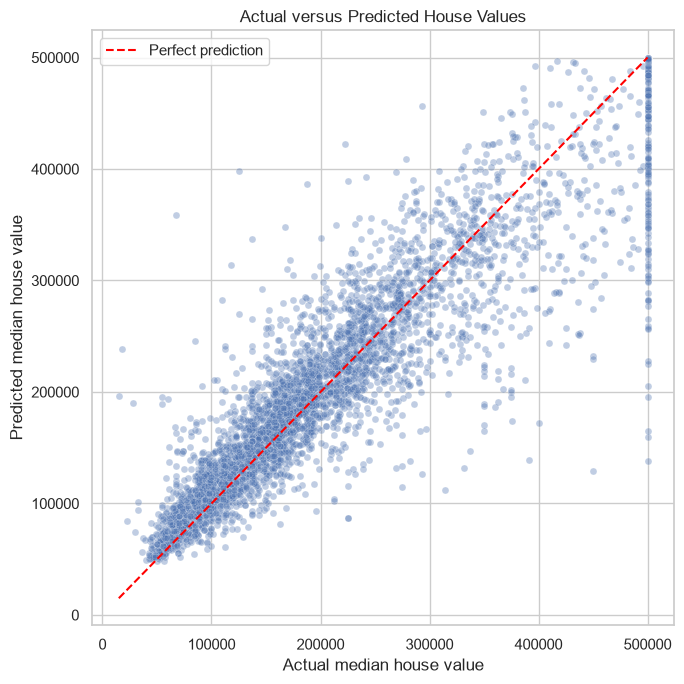

In [28]:
plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=forest_predictions,
    alpha=0.35,
    s=25
)

minimum_value = min(
    y_test.min(),
    forest_predictions.min()
)

maximum_value = max(
    y_test.max(),
    forest_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.title("Actual versus Predicted House Values")
plt.xlabel("Actual median house value")
plt.ylabel("Predicted median house value")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
calibration_predictions = random_forest_pipeline.predict(
    X_calibration
)

calibration_residuals = np.abs(
    y_calibration.to_numpy()
    - calibration_predictions
)

alpha = 0.10
n_calibration = len(calibration_residuals)

conformal_level = np.ceil(
    (n_calibration + 1)
    * (1 - alpha)
) / n_calibration

conformal_level = min(
    conformal_level,
    1.0
)

conformal_quantile = np.quantile(
    calibration_residuals,
    conformal_level,
    method="higher"
)

print(f"Target coverage: {1 - alpha:.0%}")
print(f"Conformal quantile: ${conformal_quantile:,.2f}")

Target coverage: 90%
Conformal quantile: $73,821.24


In [30]:
lower_bounds = (
    forest_predictions
    - conformal_quantile
)

upper_bounds = (
    forest_predictions
    + conformal_quantile
)

# House values cannot be negative
lower_bounds = np.maximum(
    lower_bounds,
    0
)

In [31]:
is_covered = (
    (y_test.to_numpy() >= lower_bounds)
    & (y_test.to_numpy() <= upper_bounds)
)

empirical_coverage = is_covered.mean()

interval_widths = (
    upper_bounds
    - lower_bounds
)

average_interval_width = interval_widths.mean()

print(f"Target coverage:    {1 - alpha:.1%}")
print(f"Observed coverage:  {empirical_coverage:.1%}")
print(
    "Average interval width: "
    f"${average_interval_width:,.2f}"
)

Target coverage:    90.0%
Observed coverage:  89.4%
Average interval width: $147,135.01


In [32]:
prediction_results_df = pd.DataFrame(
    {
        "actual_value": y_test.to_numpy(),
        "predicted_value": forest_predictions,
        "lower_bound": lower_bounds,
        "upper_bound": upper_bounds,
        "absolute_error": np.abs(
            y_test.to_numpy()
            - forest_predictions
        ),
        "covered": is_covered
    },
    index=y_test.index
)

prediction_results_df.head(10)

,actual_value,predicted_value,lower_bound,upper_bound,absolute_error,covered
20046,47700.0,51650.683730,0.000000,125471.920899,3950.683730,True
3024,45800.0,69940.773280,0.000000,143762.010450,24140.773280,True
15663,500001.0,452368.203701,378546.966532,526189.440870,47632.796299,True
20484,218600.0,254798.475635,180977.238466,328619.712804,36198.475635,True
9814,278000.0,266757.163817,192935.926647,340578.400986,11242.836183,True
13311,158700.0,158939.298280,85118.061111,232760.535450,239.298280,True
7113,198200.0,237472.608690,163651.371521,311293.845860,39272.608690,True
7668,157500.0,169479.418902,95658.181733,243300.656071,11979.418902,True
18246,340000.0,275554.893450,201733.656280,349376.130619,64445.106550,True
5723,446600.0,482061.207454,408239.970284,555882.444623,35461.207454,True


In [33]:
display_columns = [
    "actual_value",
    "predicted_value",
    "lower_bound",
    "upper_bound",
    "absolute_error",
    "covered"
]

prediction_results_df[
    display_columns
].sample(
    10,
    random_state=RANDOM_STATE
).round(2)

,actual_value,predicted_value,lower_bound,upper_bound,absolute_error,covered
3752,238500.0,258640.68,184819.45,332461.92,20140.68,True
16705,329700.0,237452.44,163631.20,311273.67,92247.56,False
2915,95200.0,102311.34,28490.10,176132.58,7111.34,True
9728,245100.0,241812.52,167991.29,315633.76,3287.48,True
3352,64100.0,80639.48,6818.24,154460.71,16539.48,True
18318,376600.0,330284.30,256463.06,404105.53,46315.70,True
10337,230700.0,249865.15,176043.92,323686.39,19165.15,True
6483,175200.0,219864.40,146043.17,293685.64,44664.40,True
17798,416700.0,496659.22,422837.99,570480.46,79959.22,False
12532,93800.0,101487.36,27666.12,175308.60,7687.36,True


### Conformal prediction results

The absolute calibration residuals produced a conformal quantile of
$73,821.24. Each point prediction was therefore expanded by approximately
$73,821 in both directions, except where the lower bound was clipped at zero.

The intended coverage was 90%, while the observed test coverage was 89.4%.
This is very close to the requested level: approximately 89 out of every
100 test-set house values fell inside their prediction intervals.

The average interval width was $147,135.01. Although the intervals achieved
near-target overall coverage, their relatively large width shows that the
model still has substantial uncertainty at the individual-district level.

The observed coverage does not need to equal exactly 90% on one finite test
set. Conformal prediction provides a marginal coverage guarantee under
exchangeability assumptions, while the observed test proportion can vary
slightly around the target.

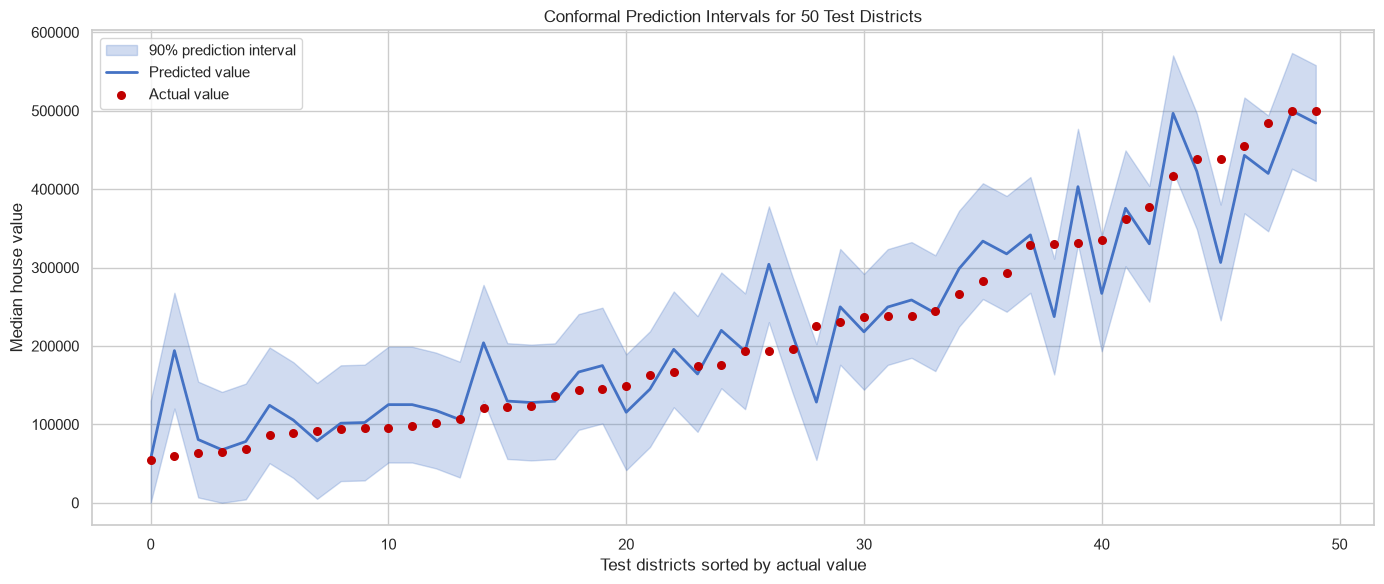

In [34]:
interval_sample = (
    prediction_results_df
    .sample(
        n=50,
        random_state=RANDOM_STATE
    )
    .sort_values("actual_value")
    .reset_index(drop=True)
)

positions = np.arange(
    len(interval_sample)
)

plt.figure(figsize=(14, 6))

plt.fill_between(
    positions,
    interval_sample["lower_bound"],
    interval_sample["upper_bound"],
    alpha=0.25,
    color="#4472C4",
    label="90% prediction interval"
)

plt.plot(
    positions,
    interval_sample["predicted_value"],
    color="#4472C4",
    linewidth=2,
    label="Predicted value"
)

plt.scatter(
    positions,
    interval_sample["actual_value"],
    color="#C00000",
    s=30,
    label="Actual value",
    zorder=3
)

plt.title("Conformal Prediction Intervals for 50 Test Districts")
plt.xlabel("Test districts sorted by actual value")
plt.ylabel("Median house value")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
prediction_results_df["value_group"] = pd.qcut(
    prediction_results_df["actual_value"],
    q=4,
    labels=[
        "Lowest-value districts",
        "Lower-middle districts",
        "Upper-middle districts",
        "Highest-value districts"
    ]
)

value_group_analysis_df = (
    prediction_results_df
    .groupby(
        "value_group",
        observed=True
    )
    .agg(
        observations=(
            "actual_value",
            "size"
        ),
        mean_actual_value=(
            "actual_value",
            "mean"
        ),
        MAE=(
            "absolute_error",
            "mean"
        ),
        coverage=(
            "covered",
            "mean"
        ),
        average_interval_width=(
            "upper_bound",
            lambda upper:
                (
                    upper
                    - prediction_results_df.loc[
                        upper.index,
                        "lower_bound"
                    ]
                ).mean()
        )
    )
    .reset_index()
)

value_group_analysis_df

,value_group,observations,mean_actual_value,MAE,coverage,average_interval_width
0,Lowest-value districts,1032,85757.750969,20216.283802,0.965116,145616.804773
1,Lower-middle districts,1032,150443.120155,24582.863112,0.958333,147638.301997
2,Upper-middle districts,1032,216101.841085,28874.698969,0.926357,147642.474339
3,Highest-value districts,1032,369698.526163,55572.574330,0.726744,147642.474339


### Coverage and error by house-value group

| House-value group | Mean actual value | MAE | Coverage |
|---|---:|---:|---:|
| Lowest-value districts | $85,757.75 | $20,216.28 | 96.5% |
| Lower-middle districts | $150,443.12 | $24,582.86 | 95.8% |
| Upper-middle districts | $216,101.84 | $28,874.70 | 92.6% |
| Highest-value districts | $369,698.53 | $55,572.57 | 72.7% |

Prediction difficulty increased with actual house value. The lowest-value
districts had an MAE of approximately $20,216, while the highest-value
districts had an MAE of approximately $55,573.

Coverage also declined as house value increased. The three lower groups
exceeded the 90% target, but coverage for the highest-value group was only
72.7%. Therefore, the overall coverage of 89.4% hides a substantial weakness
for expensive districts.

The intervals had almost the same width across all four groups because the
basic split conformal method uses one global residual quantile. The slightly
smaller width in the lowest-value group was caused by negative lower bounds
being clipped to zero.

These findings illustrate the difference between marginal and conditional
coverage. The method achieved near-90% coverage across the complete test set,
but it did not provide equally reliable intervals for every part of the
target distribution.

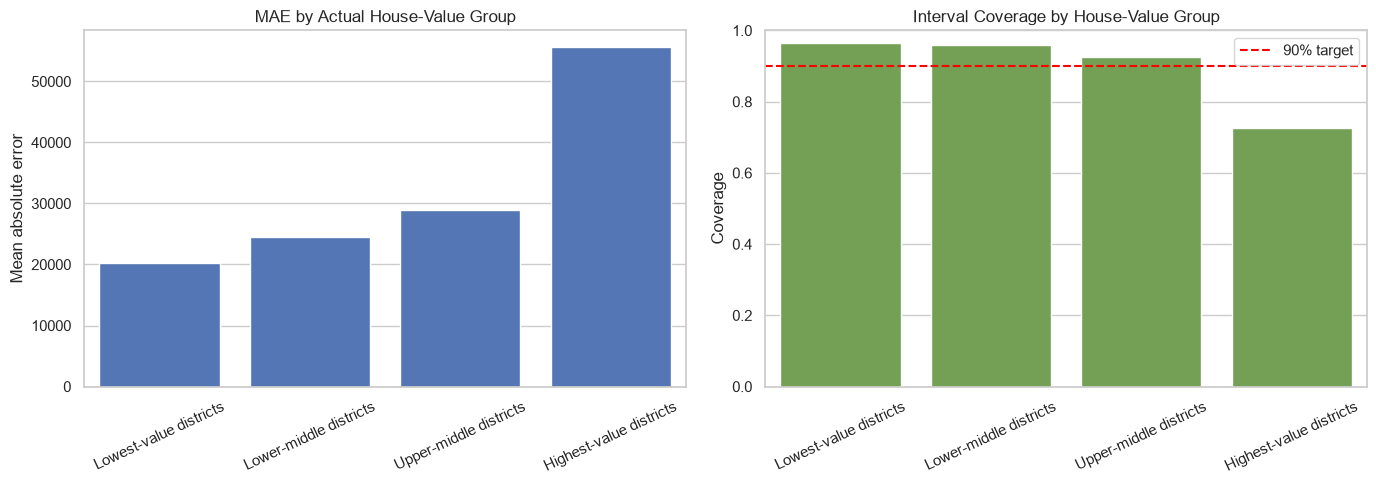

In [36]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=value_group_analysis_df,
    x="value_group",
    y="MAE",
    ax=axes[0],
    color="#4472C4"
)

axes[0].set_title("MAE by Actual House-Value Group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean absolute error")
axes[0].tick_params(
    axis="x",
    rotation=25
)

sns.barplot(
    data=value_group_analysis_df,
    x="value_group",
    y="coverage",
    ax=axes[1],
    color="#70AD47"
)

axes[1].axhline(
    0.90,
    linestyle="--",
    color="red",
    label="90% target"
)

axes[1].set_title("Interval Coverage by House-Value Group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Coverage")
axes[1].set_ylim(0, 1)
axes[1].tick_params(
    axis="x",
    rotation=25
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
fitted_preprocessor = (
    random_forest_pipeline
    .named_steps["preprocessor"]
)

fitted_model = (
    random_forest_pipeline
    .named_steps["model"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": fitted_model.feature_importances_
        }
    )
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance_df.head(15)

,feature,importance
7,numeric__median_income,0.479937
9,categorical__ocean_proximity_INLAND,0.156318
0,numeric__longitude,0.103951
1,numeric__latitude,0.095637
2,numeric__housing_median_age,0.049483
5,numeric__population,0.033229
3,numeric__total_rooms,0.023779
4,numeric__total_bedrooms,0.023673
6,numeric__households,0.018580
8,categorical__ocean_proximity_<1H OCEAN,0.007544


### Feature-importance findings

Median income was the most influential feature, accounting for approximately
48.0% of the Random Forest's total impurity-based importance.

The next most influential features were:

- Inland ocean-proximity indicator: 15.6%
- Longitude: 10.4%
- Latitude: 9.6%
- Housing median age: 4.9%
- Population: 3.3%

These results show that the model relied primarily on economic conditions
and geographic location. Median income captures local purchasing power,
while ocean proximity, longitude and latitude help distinguish coastal,
inland and metropolitan districts.

The `ISLAND` indicator had almost no measured importance. However, the
dataset contains only five island observations, so the model had insufficient
evidence to learn a reliable island-specific pattern.

Random Forest feature importance measures how useful a variable was for
constructing tree splits. It does not demonstrate that a feature causes
house values to change. Impurity-based importance can also favour variables
that provide many possible split points.

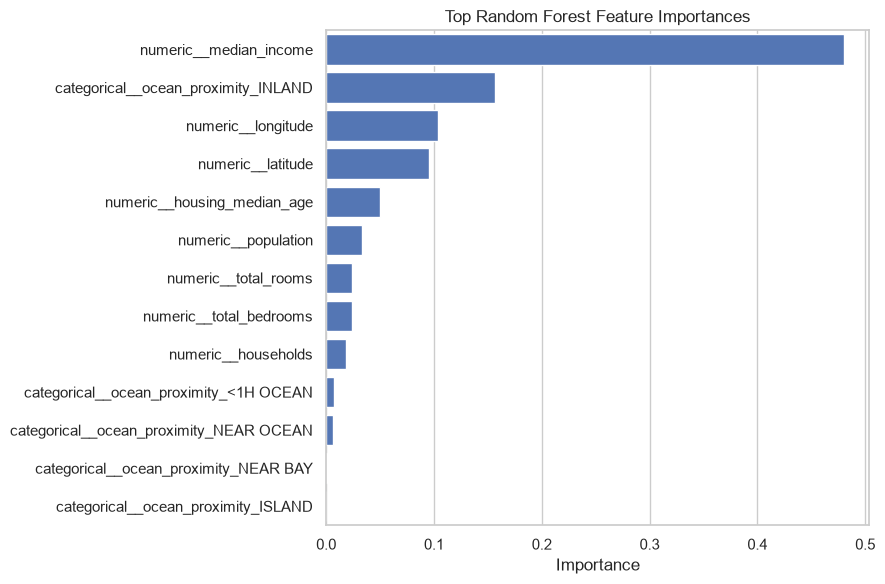

In [38]:
top_features_df = feature_importance_df.head(15)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features_df,
    x="importance",
    y="feature",
    color="#4472C4"
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()